
=== KMEANS Crosstab ===
diagnosis       PE  non-PE
cluster_kmeans            
0               49      15
1               31      62

=== GMM Crosstab ===
diagnosis    PE  non-PE
cluster_gmm            
0            52      15
1            28      62

=== ARI Scores ===
KMeans ARI: 0.1662357574337843
GMM ARI: 0.199485525504093


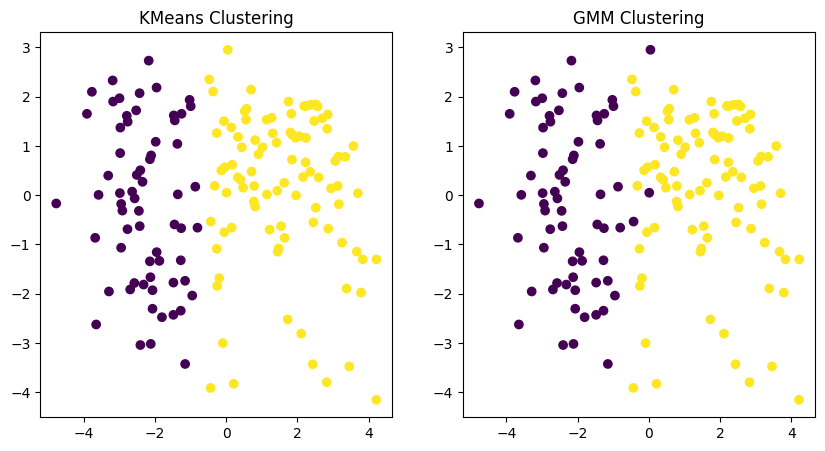

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_excel("donnees_pretraitees.xlsx")

# =========================
# 2. CLEAN DATA
# =========================

# remplacer virgules par points
df = df.replace(',', '.', regex=True)

# convertir colonnes numériques
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# =========================
# 3. PREP FEATURES
# =========================

# garder target pour évaluation
y = df['diagnosis']

# enlever colonnes inutiles
X = df.drop(columns=['gsm', 'title', 'diagnosis'])

# encoder variables catégorielles
X = pd.get_dummies(X, drop_first=True)

# =========================
# 4. SCALE
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 5. PCA (visualisation)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 6. KMEANS
# =========================
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = clusters_kmeans

print("\n=== KMEANS Crosstab ===")
print(pd.crosstab(df['cluster_kmeans'], y))

# =========================
# 7. GMM
# =========================
gmm = GaussianMixture(n_components=2, random_state=42)
clusters_gmm = gmm.fit_predict(X_scaled)

df['cluster_gmm'] = clusters_gmm

print("\n=== GMM Crosstab ===")
print(pd.crosstab(df['cluster_gmm'], y))

# =========================
# 8. METRICS (optionnel)
# =========================

# encoder y en 0/1
y_encoded = y.map({'PE':1, 'non-PE':0})

print("\n=== ARI Scores ===")
print("KMeans ARI:", adjusted_rand_score(y_encoded, clusters_kmeans))
print("GMM ARI:", adjusted_rand_score(y_encoded, clusters_gmm))

# =========================
# 9. VISUALISATION
# =========================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, cmap='viridis')
plt.title("KMeans Clustering")

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_gmm, cmap='viridis')
plt.title("GMM Clustering")

plt.show()